# About Data

Dataset ini berasal dari kampanye pemasaran bank (direct marketing) yang dilakukan melalui telepon. Tujuannya adalah mengetahui apakah seorang nasabah akan berlangganan deposito berjangka (term deposit) atau tidak.

Penjelasan Variabel


1.   Data Nasabah

* age → umur nasabah (numerik)
* job → pekerjaan (admin, technician, entrepreneur, dll)
* marital → status pernikahan (married, single, divorced)
* education → tingkat pendidikan
* default → apakah punya kredit macet (yes/no)

2.   Data Finansial

* balance → saldo rata-rata rekening (numerik)
* housing → punya pinjaman rumah (yes/no)
* loan → punya pinjaman pribadi (yes/no)

3.   Data Kontak Terakhir
* contact → jenis komunikasi (cellular, telephone)
* day → hari terakhir dihubungi
* month → bulan terakhir dihubungi
* duration → durasi panggilan terakhir (detik)

4. Riwayat Kampanye
* Campaign → Jumlah kontak yang dilakukan ke nasabah selama kampanye
* pdays → Jumlah hari sejak terakhir kali nasabah dihubungi pada kampanye sebelumnya
* previous → Jumlah kontak yang dilakukan sebelum kampanye saat ini
* poutcome → Hasil dari kampanye sebelumnya

5.  Deposit (Variabel target) → Apakah nasabah melakukan deposit atau tidak



# Install dan Import Library

In [106]:
!pip install xgboost optuna openpyxl

In [107]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

import optuna
import joblib

# Load Data

In [108]:
df = pd.read_excel("/content/Dataset_Klasifikasi.xlsx")

# EDA

In [109]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (8929, 17)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8929 entries, 0 to 8928
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        8929 non-null   int64 
 1   job        8929 non-null   object
 2   marital    8929 non-null   object
 3   education  8929 non-null   object
 4   default    8929 non-null   object
 5   balance    8929 non-null   int64 
 6   housing    8929 non-null   object
 7   loan       8929 non-null   object
 8   contact    8929 non-null   object
 9   day        8929 non-null   int64 
 10  month      8929 non-null   object
 11  duration   8929 non-null   int64 
 12  campaign   8929 non-null   int64 
 13  pdays      8929 non-null   int64 
 14  previous   8929 non-null   int64 
 15  poutcome   8929 non-null   object
 16  deposit    8929 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


In [110]:
print("\nStatistik Numerik:")
df.describe()


Statistik Numerik:


,age,balance,day,duration,campaign,pdays,previous
count,8929.000000,8929.000000,8929.000000,8929.000000,8929.000000,8929.000000,8929.000000
mean,41.242356,1520.506328,15.629970,370.224549,2.506440,50.732557,0.811289
std,11.887444,3135.126582,8.445399,345.949019,2.705238,108.640328,2.207104
min,18.000000,-3058.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,121.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,549.000000,15.000000,253.000000,2.000000,-1.000000,0.000000
75%,49.000000,1714.000000,22.000000,493.000000,3.000000,2.000000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [111]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [112]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


# Visualisasi

## Distribusi Variabel Target

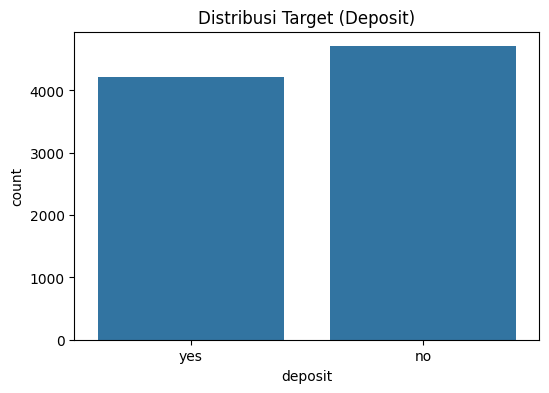

deposit
no     0.527159
yes    0.472841
Name: proportion, dtype: float64


In [113]:
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df)
plt.title('Distribusi Target (Deposit)')
plt.show()

print(df['deposit'].value_counts(normalize=True))

## Korelasi Numerik

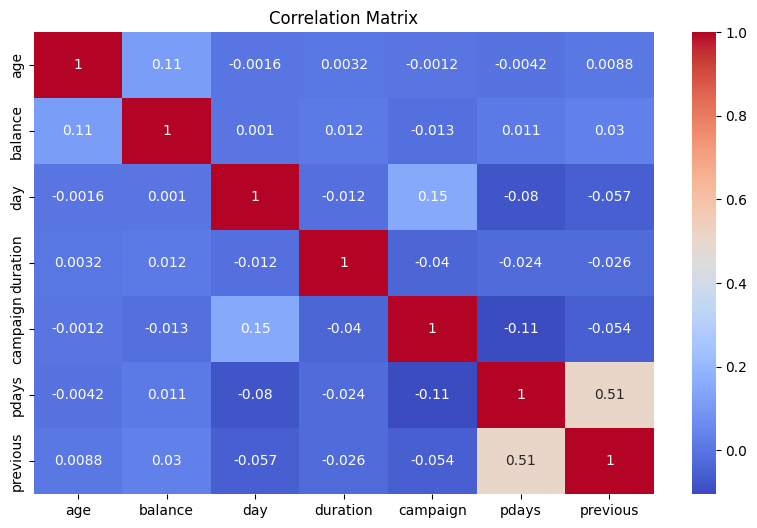

In [114]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Kategorikal VS Target

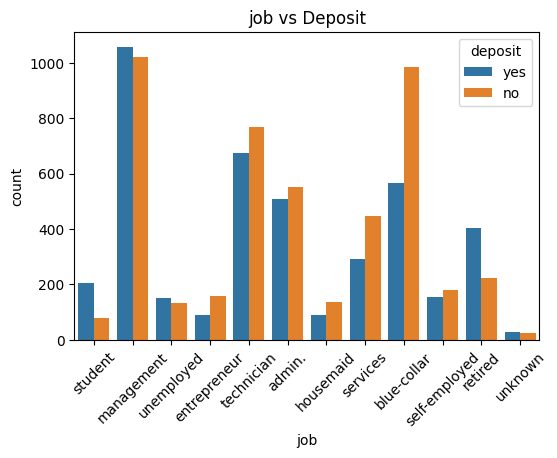

In [115]:
plt.figure(figsize=(6,4))
sns.countplot(x='job', hue='deposit', data=df)
plt.title('job vs Deposit')
plt.xticks(rotation=45)
plt.show()

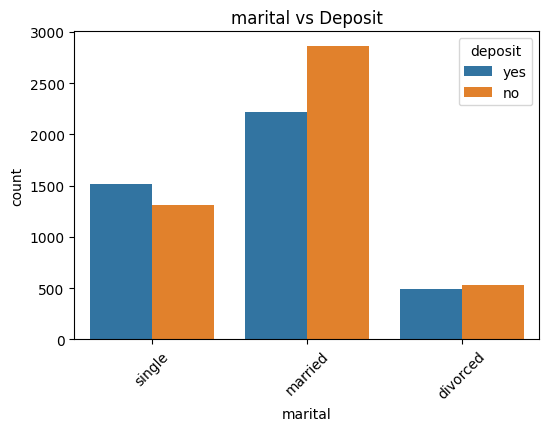

In [116]:
plt.figure(figsize=(6,4))
sns.countplot(x='marital', hue='deposit', data=df)
plt.title('marital vs Deposit')
plt.xticks(rotation=45)
plt.show()

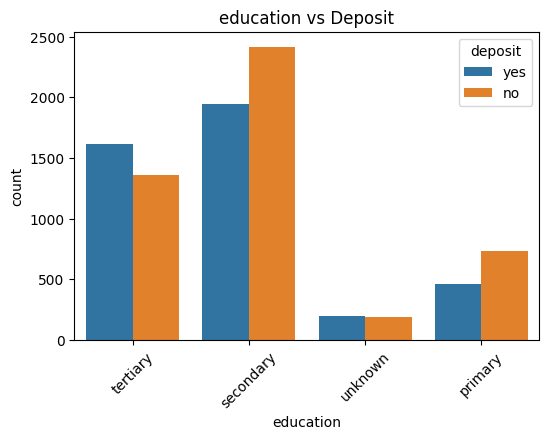

In [117]:
plt.figure(figsize=(6,4))
sns.countplot(x='education', hue='deposit', data=df)
plt.title('education vs Deposit')
plt.xticks(rotation=45)
plt.show()

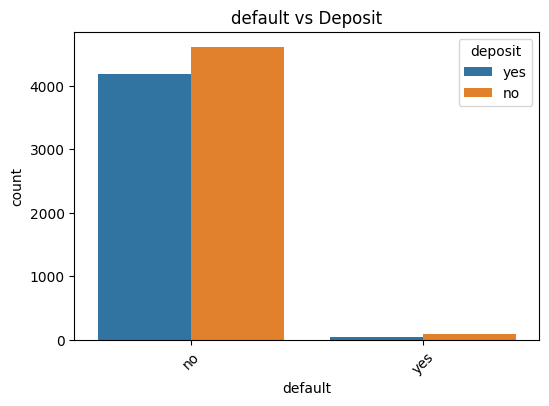

In [118]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', hue='deposit', data=df)
plt.title('default vs Deposit')
plt.xticks(rotation=45)
plt.show()

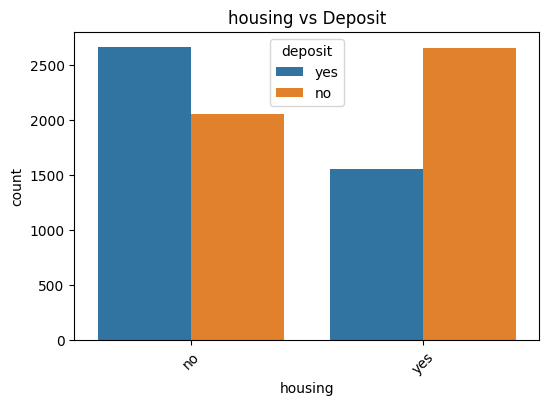

In [119]:
plt.figure(figsize=(6,4))
sns.countplot(x='housing', hue='deposit', data=df)
plt.title('housing vs Deposit')
plt.xticks(rotation=45)
plt.show()

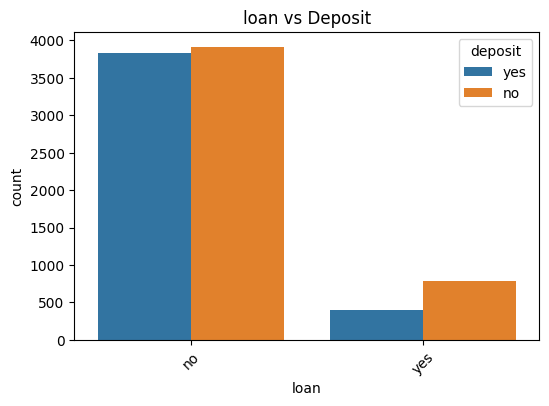

In [120]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan', hue='deposit', data=df)
plt.title('loan vs Deposit')
plt.xticks(rotation=45)
plt.show()

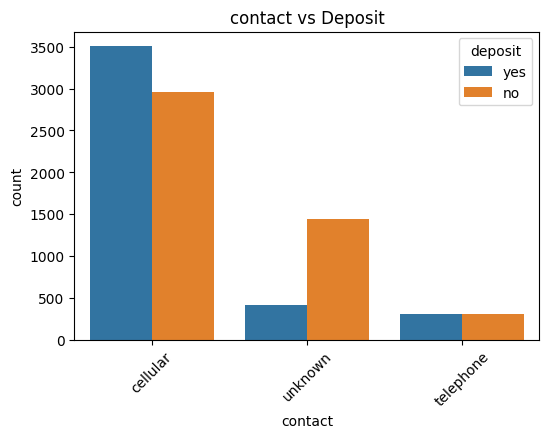

In [121]:
plt.figure(figsize=(6,4))
sns.countplot(x='contact', hue='deposit', data=df)
plt.title('contact vs Deposit')
plt.xticks(rotation=45)
plt.show()

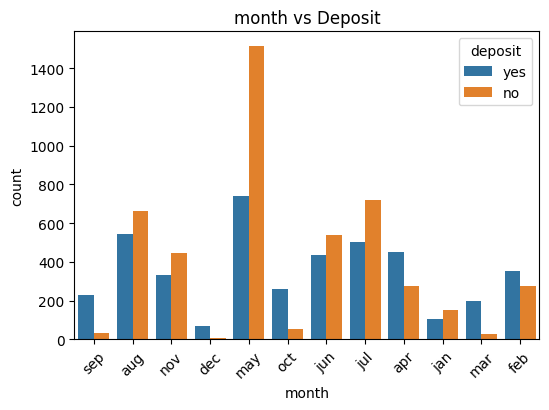

In [122]:
plt.figure(figsize=(6,4))
sns.countplot(x='month', hue='deposit', data=df)
plt.title('month vs Deposit')
plt.xticks(rotation=45)
plt.show()

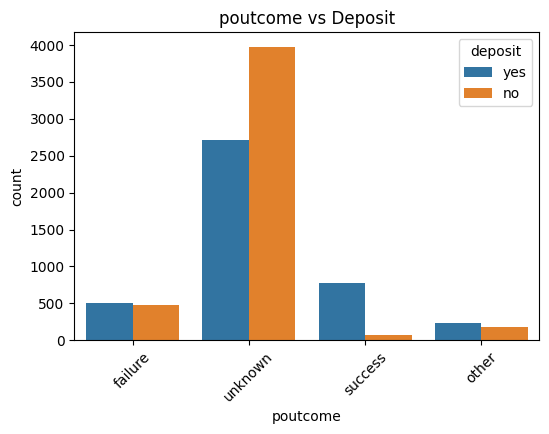

In [123]:
plt.figure(figsize=(6,4))
sns.countplot(x='poutcome', hue='deposit', data=df)
plt.title('poutcome vs Deposit')
plt.xticks(rotation=45)
plt.show()

# Preprocessing

## Feature Engineering

In [124]:
# 1. Age group
df['age_group'] = pd.cut(df['age'],
                        bins=[0, 25, 40, 60, 100],
                        labels=['young', 'adult', 'middle', 'senior'])

# 2. Campaign ratio
df['campaign_ratio'] = df['campaign'] / (df['previous'] + 1)

# 3. Pernah dihubungi sebelumnya
df['has_contacted_before'] = (df['previous'] > 0).astype(int)

# 4. Durasi call (penting)
df['long_call'] = (df['duration'] > df['duration'].median()).astype(int)

# 5. Kombinasi fitur
df['job_education'] = df['job'].astype(str) + "_" + df['education'].astype(str)

Penjelasan tiap fitur:
* age_group → mengelompokkan umur agar pola lebih mudah dikenali
* campaign_ratio → melihat intensitas kontak dibanding histori
* has_contacted_before → apakah pernah dihubungi sebelumnya
* long_call → mengidentifikasi durasi interaksi tinggi
* job_education → menggabungkan dua kategori untuk menangkap pola kompleks

## Handling Outlier

In [125]:
def cap_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

num_cols_all = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols_all:
    if col != 'deposit':
        cap_outlier(df, col)

## Encoding Variabel Target & Split Data

In [126]:
X = df.drop(columns=['deposit'])
y = df['deposit'].map({'yes': 1, 'no': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Handling Imbalanced Dataset

In [127]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

## Encoding Kolom Kategorikal

In [128]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

In [129]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Hyperparameter Tunning

In [130]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
    }

    model = Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(
            **params,
            eval_metric='logloss',
            random_state=42,
            use_label_encoder=False,
            scale_pos_weight=scale_pos_weight
        ))
    ])

    # Transform data dulu untuk early stopping
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    clf = model.named_steps['clf']

    clf.fit(
        X_train_proc, y_train,
        verbose=False
    )

    y_prob = clf.predict_proba(X_test_proc)[:, 1]

    return roc_auc_score(y_test, y_prob)

In [131]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-04-23 15:56:04,126] A new study created in memory with name: no-name-f5dd8e2f-c758-48e3-be73-8235c6f09cc2
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:56:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-04-23 15:56:04,341] Trial 0 finished with value: 0.9174678761533895 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.146558357037439, 'subsample': 0.6930586642637726, 'colsample_bytree': 0.7088669546998537, 'gamma': 4.291572392924591, 'reg_alpha': 0.07973143572166552, 'reg_lambda': 0.5916317343718366}. Best is trial 0 with value: 0.9174678761533895.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:56:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-04-23 15:56:04,672] Tria

In [132]:
print("Best Params:", study.best_params)
print("Best ROC-AUC:", study.best_value)

Best Params: {'n_estimators': 550, 'max_depth': 6, 'learning_rate': 0.026158987508206177, 'subsample': 0.6449114524089696, 'colsample_bytree': 0.9410764083973326, 'gamma': 2.638779978246177, 'reg_alpha': 0.6668353935090269, 'reg_lambda': 0.5459281303445709}
Best ROC-AUC: 0.9211858906632052


  # Traning Model Final

In [133]:
# Transform data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

best_model = XGBClassifier(
    **study.best_params,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight
)

best_model.fit(
    X_train_proc, y_train,
    eval_set=[(X_test_proc, y_test)],
    verbose=False
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:56:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9410764083973326, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.638779978246177, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.026158987508206177,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=550, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluasi Model

In [134]:
y_pred = best_model.predict(X_test_proc)
y_prob = best_model.predict_proba(X_test_proc)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.864501679731243
ROC-AUC: 0.9211858906632052

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       942
           1       0.82      0.91      0.86       844

    accuracy                           0.86      1786
   macro avg       0.87      0.87      0.86      1786
weighted avg       0.87      0.86      0.86      1786


Confusion Matrix:
 [[778 164]
 [ 78 766]]


In [135]:

joblib.dump(best_model, "model_xgb.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

# Prediksi Data Baru

In [136]:
model = joblib.load("model_xgb.pkl")
preprocessor = joblib.load("preprocessor.pkl")

df_new = pd.read_excel("/content/Dataset_Klasifikasi(target).xlsx")

# Feature engineering HARUS sama
df_new['age_group'] = pd.cut(df_new['age'],
                            bins=[0, 25, 40, 60, 100],
                            labels=['young', 'adult', 'middle', 'senior'])

df_new['campaign_ratio'] = df_new['campaign'] / (df_new['previous'] + 1)
df_new['has_contacted_before'] = (df_new['previous'] > 0).astype(int)
df_new['long_call'] = (df_new['duration'] > df_new['duration'].median()).astype(int)
df_new['job_education'] = df_new['job'].astype(str) + "_" + df_new['education'].astype(str)

# Transform
X_new = preprocessor.transform(df_new)

# Prediksi
y_pred = model.predict(X_new)
df_new['prediksi_deposit'] = ['yes' if i == 1 else 'no' for i in y_pred]

df_new.to_excel("hasil_prediksi_advanced.xlsx", index=False)

In [137]:
print(df_new.head)

<bound method NDFrame.head of       age          job   marital  education default  balance housing loan  \
0      65      retired  divorced  secondary      no      744      no   no   
1      38  blue-collar   married  secondary      no     1627      no   no   
2      35  blue-collar    single  secondary      no     4963     yes   no   
3      47  blue-collar   married  secondary      no     8229      no   no   
4      35   technician   married   tertiary      no     1473     yes   no   
...   ...          ...       ...        ...     ...      ...     ...  ...   
2228   46   unemployed   married  secondary      no      926      no   no   
2229   49   technician   married    primary      no      230     yes   no   
2230   53   technician   married   tertiary      no      431     yes   no   
2231   48   unemployed   married  secondary      no      926      no   no   
2232   34       admin.   married   tertiary      no     1636     yes  yes   

       contact  day  ... campaign  pdays  pre